Model Architecture

In [1]:
import tensorflow as tf
import tensorflow.keras.layers as L

We're using a covolutional autoencoder to for this task. The model takes an input shape (32, 32, 1) and rebuilds it while removing the noise.

In [2]:
def Encoder(x):
  x = L.Conv2D(16, kernel_size=(3, 3), strides=1, padding='same')(x)
  x = L.LeakyReLU()(x)
  x = L.AvgPool2D(pool_size=(2, 2), strides=(2, 1), padding='same')(x)

  x = L.Conv2D(32, kernel_size=(3, 3), strides=1, padding='same')(x)
  x = L.LeakyReLU()(x)
  x = L.AvgPool2D(pool_size=(2, 2), strides=(1, 2), padding='same')(x)

  x = L.Conv2D(32, kernel_size=(1, 1), strides=1, padding='same')(x)

  return x

In [3]:
def Decoder(x):
  x = L.UpSampling2D(size=(1, 2), interpolation='bilinear')(x)
  x = L.Conv2D(32, kernel_size=(3, 3), strides=1, padding='same')(x)
  x = L.Activation('swish')(x)

  x = L.UpSampling2D(size=(2, 1), interpolation='bilinear')(x)
  x = L.Conv2D(16, kernel_size=(3, 3), strides=1, padding='same')(x)
  x = L.Activation('swish')(x)

  x = L.Conv2D(1, kernel_size=(1, 1))(x)

  return x

In [4]:
def Build_AutoEncoder(input_shape=(32, 32, 1)):

  inputs = L.Input(shape=input_shape)
  encoder = Encoder(inputs)
  decoder = Decoder(encoder)

  model = tf.keras.Model(inputs=inputs, outputs=decoder)

  model.compile(loss = tf.keras.losses.MeanSquaredError(),
                optimizer = tf.keras.optimizers.Adam(learning_rate=0.001))
  return model

In [5]:
model = Build_AutoEncoder(input_shape=(32, 32, 1))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 16, 32, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 16, 16, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 16, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 1)      │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,745 (77.13 KB)

 Trainable params: 19,745 (77.13 KB)

 Non-trainable params: 0 (0.00 B)

Dataset

In [6]:
import pandas as pd
import numpy as np
#Loading the dataset

data = np.load('/content/data.npy')
labels = np.load('/content/labels.npy')

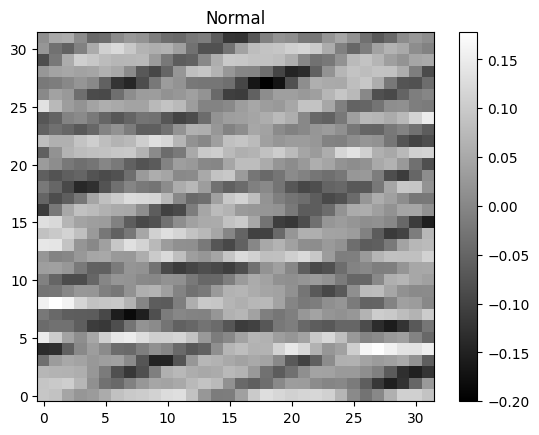

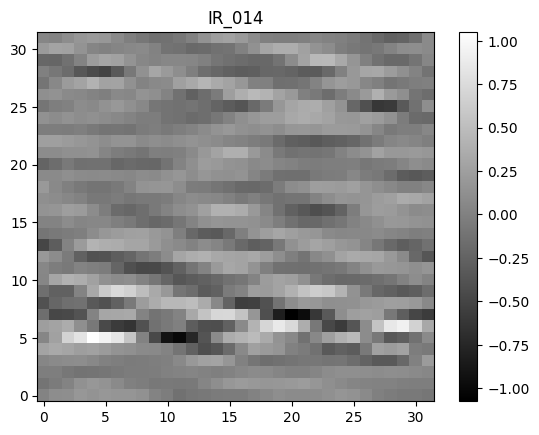

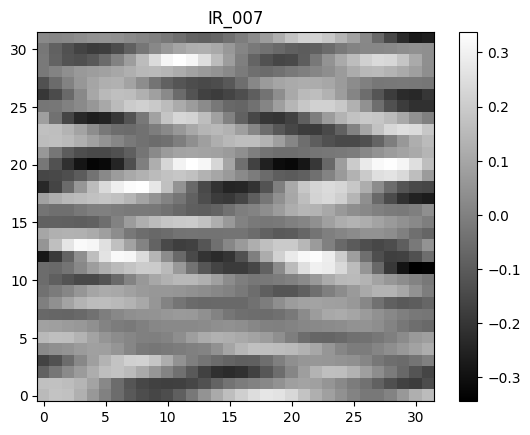

In [7]:
import matplotlib.pyplot as plt

#Samples from the dataset
plt.imshow(data[4200], cmap='gray', aspect='auto', origin='lower')
plt.colorbar()
plt.title(labels[4200])
plt.show()

plt.imshow(data[2000], cmap='gray', aspect='auto', origin='lower')
plt.colorbar()
plt.title(labels[2000])
plt.show()

plt.imshow(data[300], cmap='gray', aspect='auto', origin='lower')
plt.colorbar()
plt.title(labels[1500])
plt.show()

In [8]:
import numpy as np

# Load arrays
X = np.load("data.npy", allow_pickle=True)      # shape: (4600, 32, 32)
y = np.load("labels.npy", allow_pickle=True)    # shape: (4600,)

print("Original shape:", X.shape)
print("Unique labels:", np.unique(y))

# ---- Select only NORMAL samples ----
normal_mask = (y == "Normal")

X_normal = X[normal_mask]   # train autoencoder on this
X_test   = X                # evaluate on full dataset
y_test   = y

print("Normal samples:", X_normal.shape)

# ---- Add channel dimension (CNN expects this) ----
X_normal = X_normal[..., None]   # (N, 32, 32, 1)
X_test   = X_test[..., None]

print("After channel add:", X_normal.shape)

# ---- Normalize using ONLY normal data ----
mean = X_normal.mean()
std  = X_normal.std() + 1e-8

X_normal = (X_normal - mean) / std
X_test   = (X_test   - mean) / std

print("Normalization done")


Original shape: (4600, 32, 32)
Unique labels: ['Ball_007' 'Ball_014' 'Ball_021' 'IR_007' 'IR_014' 'IR_021' 'Normal'
 'OR_007' 'OR_014' 'OR_021']
Normal samples: (460, 32, 32)
After channel add: (460, 32, 32, 1)
Normalization done


In [10]:
model = Build_AutoEncoder(input_shape=(32, 32, 1)) #Instantiating the model
model.fit(X_normal, y=X_normal, batch_size=16, epochs=50, verbose=1) #Training the model

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.8808
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.6758
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.5640
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.4035
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.3330
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.2980
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 0.2627
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.2297
Epoch 9/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.2025
Epoch 10/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.1891
Epoch 11/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.1680
Epoch 12/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.1569
Epoch 13/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.1479
Epoch 14/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.1419
Epoch 15/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.1361
Ep

In [ ]:
model.save('Conv_Autoencoder_16x16.keras') #Save the model to load it for predictions(16x16 is the final feature map size in the bottleneck layer).

Evaluation

In [11]:
recon = model.predict(X_test, batch_size=128) #Reconstruct test images using the trained autoencoder

36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step


In [13]:
error = np.mean((X_test - recon)**2, axis=(1,2,3)) #Meansquared Error between True values and Predicted values

In [16]:
##Plotting the statistics

In [14]:
error_normal = error[y_test == 'Normal']
error_faulty = error[y_test != 'Normal']

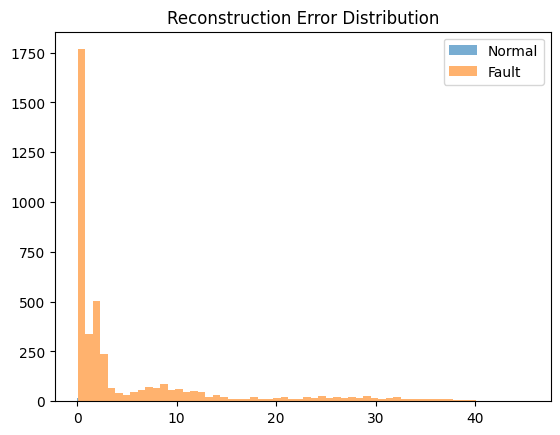

In [15]:
import matplotlib.pyplot as plt

plt.hist(error_normal, bins=60, alpha=0.6, label="Normal")
plt.hist(error_faulty, bins=60, alpha=0.6, label="Fault")
plt.legend()
plt.title("Reconstruction Error Distribution")
plt.show()
